<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/Lasso%20Regression%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     GENERATED STUDENT DATASET

First 10 Rows:
   Study_Hours  Attendance  Previous_Score  Assignment_Score  Sleep_Hours  \
0         4.37          94              42                61         4.83   
1         9.56          81              92                73         4.93   
2         7.59          79              94                86         8.19   
3         6.39          96              84                47         5.66   
4         2.40          84              62                79         5.56   
5         2.40          89              62                88         5.14   
6         1.52          65              71                83         7.04   
7         8.80          62              75                58         5.90   
8         6.41          99              70                81         7.72   
9         7.37          91              61                80         5.03   

   Practice_Tests  Internet_Hours  Final_Score  
0               2            6.24    87.236884  
1      

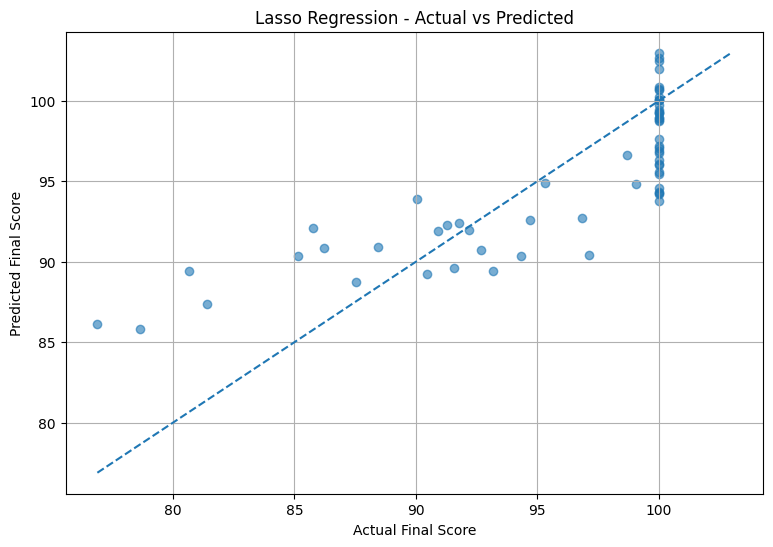

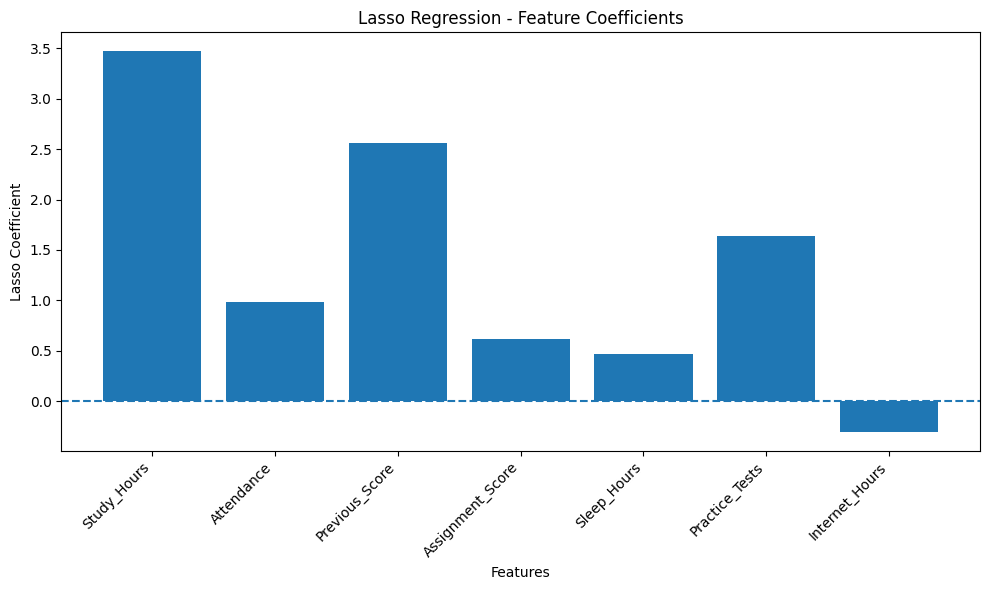

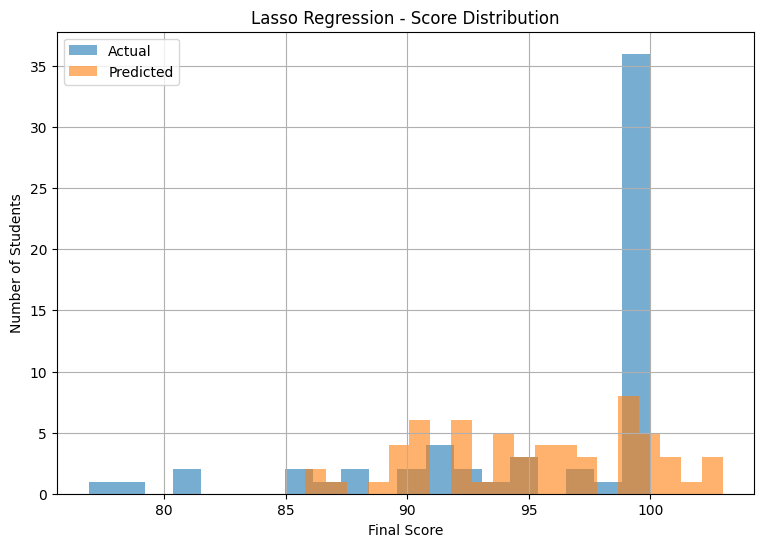


           FINAL RESULT
Lasso R² Score = 0.6480
Lasso R² Percentage = 64.80%
Lasso RMSE = 3.6953

Graphs Generated:
1. Actual vs Predicted
2. Feature Coefficients
3. Actual vs Predicted Distribution


In [15]:
# ============================================================
# LASSO REGRESSION - STUDENT PERFORMANCE DATASET
# DATASET GENERATED INSIDE THE CODE
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score


# ------------------------------------------------------------
# 2. GENERATE STUDENT PERFORMANCE DATASET
# ------------------------------------------------------------

np.random.seed(42)

n = 300

# Study hours per day
study_hours = np.round(
    np.random.uniform(1, 10, n),
    2
)

# Attendance percentage
attendance = np.random.randint(
    50, 101, n
)

# Previous exam score
previous_score = np.random.randint(
    35, 96, n
)

# Assignment score
assignment_score = np.random.randint(
    40, 101, n
)

# Sleep hours
sleep_hours = np.round(
    np.random.uniform(4, 9, n),
    2
)

# Number of practice tests
practice_tests = np.random.randint(
    0, 15, n
)

# Internet usage hours
internet_hours = np.round(
    np.random.uniform(0, 8, n),
    2
)


# ------------------------------------------------------------
# 3. GENERATE FINAL EXAM SCORE
# ------------------------------------------------------------

final_score = (
    15
    + 4.5 * study_hours
    + 0.20 * attendance
    + 0.40 * previous_score
    + 0.15 * assignment_score
    + 1.5 * sleep_hours
    + 1.2 * practice_tests
    - 0.8 * internet_hours
)


# Add random noise
final_score += np.random.normal(
    0,
    5,
    n
)


# Keep marks between 0 and 100
final_score = np.clip(
    final_score,
    0,
    100
)


# ------------------------------------------------------------
# 4. CREATE DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame({

    "Study_Hours": study_hours,

    "Attendance": attendance,

    "Previous_Score": previous_score,

    "Assignment_Score": assignment_score,

    "Sleep_Hours": sleep_hours,

    "Practice_Tests": practice_tests,

    "Internet_Hours": internet_hours,

    "Final_Score": final_score

})


# ------------------------------------------------------------
# 5. DISPLAY DATASET
# ------------------------------------------------------------

print("======================================")
print("     GENERATED STUDENT DATASET")
print("======================================")

print("\nFirst 10 Rows:")
print(df.head(10))

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())


# ------------------------------------------------------------
# 6. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    "Final_Score",
    axis=1
)

y = df["Final_Score"]


# ------------------------------------------------------------
# 7. TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)


print("\nTraining Data:", X_train.shape)

print(
    "Testing Data:",
    X_test.shape
)


# ------------------------------------------------------------
# 8. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ------------------------------------------------------------
# 9. CREATE LASSO REGRESSION MODEL
# ------------------------------------------------------------

model = Lasso(
    alpha=0.1,
    max_iter=10000,
    random_state=42
)


# ------------------------------------------------------------
# 10. TRAIN MODEL
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 11. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ------------------------------------------------------------
# 12. CALCULATE R² SCORE
# ------------------------------------------------------------

r2 = r2_score(
    y_test,
    y_pred
)


# ------------------------------------------------------------
# 13. CALCULATE RMSE
# ------------------------------------------------------------

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


# ------------------------------------------------------------
# 14. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n======================================")
print("        LASSO REGRESSION RESULTS")
print("======================================")

print(
    f"R² Score = {r2:.4f}"
)

print(
    f"R² Score Percentage = "
    f"{r2 * 100:.2f}%"
)

print(
    f"RMSE = {rmse:.4f}"
)


# ------------------------------------------------------------
# 15. LASSO COEFFICIENTS
# ------------------------------------------------------------

print("\nLasso Coefficients:")

coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_

})

print(
    coefficients
)


# ============================================================
# GRAPH 1 - ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)


# Perfect prediction line

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(

    [min_value, max_value],

    [min_value, max_value],

    linestyle="--"
)


plt.xlabel(
    "Actual Final Score"
)

plt.ylabel(
    "Predicted Final Score"
)

plt.title(
    "Lasso Regression - Actual vs Predicted"
)

plt.grid(True)

plt.show()


# ============================================================
# GRAPH 2 - FEATURE COEFFICIENTS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Lasso Coefficient"
)

plt.title(
    "Lasso Regression - Feature Coefficients"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 3 - ACTUAL VS PREDICTED DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    y_test,
    bins=20,
    alpha=0.6,
    label="Actual"
)

plt.hist(
    y_pred,
    bins=20,
    alpha=0.6,
    label="Predicted"
)

plt.xlabel(
    "Final Score"
)

plt.ylabel(
    "Number of Students"
)

plt.title(
    "Lasso Regression - Score Distribution"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("           FINAL RESULT")
print("======================================")

print(
    f"Lasso R² Score = {r2:.4f}"
)

print(
    f"Lasso R² Percentage = "
    f"{r2 * 100:.2f}%"
)

print(
    f"Lasso RMSE = {rmse:.4f}"
)

print("\nGraphs Generated:")

print(
    "1. Actual vs Predicted"
)

print(
    "2. Feature Coefficients"
)

print(
    "3. Actual vs Predicted Distribution"
)